# Phase 2 -- Noise robustness (hybrid quantum CNN)

This notebook explores how the hybrid model responds to simulated depolarizing noise on its quantum layer, using the subset split (digits 0/1/2, 300 train / 100 test per class).

- **Option 1 (eval sweep)**: the already-trained, noise-free `hybrid_subset` model, re-evaluated at increasing noise levels -- no retraining.
- **Option 2 (noise-aware training)**: three independent models trained from scratch with fixed noise present *during* training (10% / 20% / 30%), each evaluated at its own training noise level.

It loads the saved configs and metrics for both options, compares final numbers, plots the noise sweep and the Option 1 vs Option 2 combined comparison, and evaluates confusion matrices for the noise-trained models (plus the noise-free baseline) when weights are present.

In [1]:
import os
import sys
from pathlib import Path

import pandas as pd
import torch
import torch.nn as nn
import yaml
import matplotlib.pyplot as plt
from IPython.display import Image, display

project_root = Path.cwd().resolve()
if not (project_root / 'results').exists():
    project_root = Path('d:/Dissertation/qcnn-dissertation').resolve()

sys.path.insert(0, str(project_root))

from src.data.dataset import get_dataloaders
from src.models.hybrid_cnn import HybridCNN
from src.training.engine import evaluate
from src.training.metrics import confusion_matrix_fig
from src.utils.plotting import plot_noise_sweep, plot_comparison

print('Imports OK')
print(f'Project root: {project_root}')

Imports OK
Project root: D:\Dissertation\qcnn-dissertation


## Configuration

Points to the noise-free baseline (for reference), the Option 1 eval-sweep config/results, and the three Option 2 training configs/results.

In [2]:
def load_config(config_path):
    with open(config_path, 'r', encoding='utf-8') as f:
        config = yaml.safe_load(f)
    config['dataset']['data_root'] = str(project_root / 'data')
    return config

BASE_HYBRID = {
    'label': 'hybrid_subset_baseline',
    'noise_prob': 0.0,
    'config': project_root / 'configs' / 'base' / 'hybrid_subset.yaml',
    'results_dir': project_root / 'results' / 'base' / 'hybrid_subset',
}

OPTION1 = {
    'label': 'noise_eval_sweep',
    'config': project_root / 'configs' / 'noise' / 'hybrid_noise_eval.yaml',
    'results_dir': project_root / 'results' / 'noise' / 'eval_sweep',
}

OPTION2_RUNS = [
    {
        'label': f'train_{level}',
        'noise_prob': level / 100,
        'config': project_root / 'configs' / 'noise' / f'hybrid_noise_train_{level}.yaml',
        'results_dir': project_root / 'results' / 'noise' / f'train_{level}',
    }
    for level in [10, 20, 30]
]

print('Baseline:', BASE_HYBRID['config'])
print('Option 1:', OPTION1['config'])
for spec in OPTION2_RUNS:
    print('Option 2:', spec['config'])

Baseline: D:\Dissertation\qcnn-dissertation\configs\base\hybrid_subset.yaml
Option 1: D:\Dissertation\qcnn-dissertation\configs\noise\hybrid_noise_eval.yaml
Option 2: D:\Dissertation\qcnn-dissertation\configs\noise\hybrid_noise_train_10.yaml
Option 2: D:\Dissertation\qcnn-dissertation\configs\noise\hybrid_noise_train_20.yaml
Option 2: D:\Dissertation\qcnn-dissertation\configs\noise\hybrid_noise_train_30.yaml


## 1. Noise experiment configuration summary

Confirms every noise config shares the same subset `dataset` block as the base models, and shows the noise level each run trains or evaluates at.

In [3]:
rows = []

base_cfg = load_config(BASE_HYBRID['config'])
rows.append({
    'run': BASE_HYBRID['label'],
    'noise_prob': 0.0,
    'n_qubits': base_cfg['model'].get('n_qubits'),
    'n_qlayers': base_cfg['model'].get('n_qlayers'),
    'epochs': base_cfg['training'].get('epochs'),
    'data_seed': base_cfg.get('data_seed'),
    'training_seed': base_cfg.get('training_seed'),
})

opt1_cfg = load_config(OPTION1['config'])
rows.append({
    'run': OPTION1['label'],
    'noise_prob': opt1_cfg['noise']['levels'],
    'n_qubits': opt1_cfg['model'].get('n_qubits'),
    'n_qlayers': opt1_cfg['model'].get('n_qlayers'),
    'epochs': 'n/a (eval only)',
    'data_seed': opt1_cfg.get('data_seed'),
    'training_seed': opt1_cfg.get('training_seed'),
})

for spec in OPTION2_RUNS:
    cfg = load_config(spec['config'])
    rows.append({
        'run': spec['label'],
        'noise_prob': cfg['model'].get('noise_prob'),
        'n_qubits': cfg['model'].get('n_qubits'),
        'n_qlayers': cfg['model'].get('n_qlayers'),
        'epochs': cfg['training'].get('epochs'),
        'data_seed': cfg.get('data_seed'),
        'training_seed': cfg.get('training_seed'),
    })

config_summary_df = pd.DataFrame(rows)
display(config_summary_df)

,run,noise_prob,n_qubits,n_qlayers,epochs,data_seed,training_seed
0,hybrid_subset_baseline,0.0,4,2,15,42,42
1,noise_eval_sweep,"[0.0, 0.01, 0.05, 0.1, 0.2]",4,2,n/a (eval only),42,42
2,train_10,0.1,4,2,15,42,42
3,train_20,0.2,4,2,15,42,42
4,train_30,0.3,4,2,15,42,42


## 2. Option 1 -- evaluation sweep (no retraining)

Loads `results/noise/eval_sweep/metrics.csv` (one row per noise level) and plots accuracy/F1 vs noise probability.

,noise_level,test_loss,seed,accuracy,f1_macro,precision_macro,recall_macro
0,0.00,0.474365,42,0.976667,0.976814,0.978193,0.976667
1,0.01,0.479823,42,0.976667,0.976814,0.978193,0.976667
2,0.05,0.502375,42,0.973333,0.973503,0.975309,0.973333
3,0.10,0.532232,42,0.973333,0.973503,0.975309,0.973333
4,0.20,0.597816,42,0.973333,0.973503,0.975309,0.973333


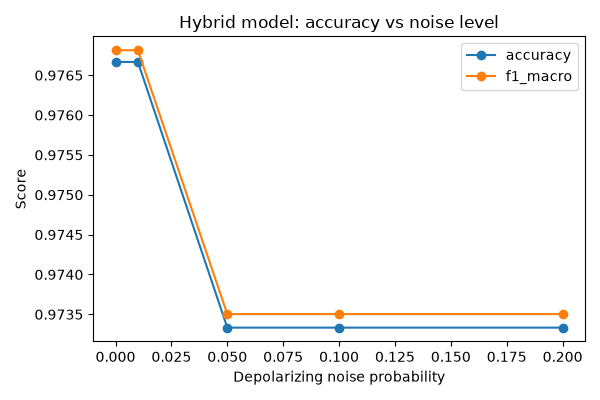

In [4]:
eval_csv = OPTION1['results_dir'] / 'metrics.csv'
if eval_csv.exists():
    eval_df = pd.read_csv(eval_csv).sort_values('noise_level')
    display(eval_df)
    sweep_fig_path = project_root / 'figures' / 'noise_eval_sweep.png'
    plot_noise_sweep(eval_csv, sweep_fig_path)
    display(Image(filename=str(sweep_fig_path)))
else:
    eval_df = None
    print(
        f'No metrics.csv found at {eval_csv} -- run:\n'
        '  python -m src.experiments.run_noise_eval --config configs/noise/hybrid_noise_eval.yaml'
    )

## 3. Option 2 -- noise-aware training (fixed levels)

Loads the per-epoch `metrics.csv` for each of the three training runs, shows the final-epoch summary, and overlays their training curves.

In [5]:
option2_metrics = {}
for spec in OPTION2_RUNS:
    csv_path = spec['results_dir'] / 'metrics.csv'
    if csv_path.exists():
        option2_metrics[spec['label']] = pd.read_csv(csv_path)
        print(f"{spec['label']}: loaded {len(option2_metrics[spec['label']])} epochs")
    else:
        print(f"{spec['label']}: no metrics.csv found")

metric_cols = ['accuracy', 'f1_macro', 'precision_macro', 'recall_macro', 'test_loss', 'epoch_time_sec']
final_rows = []
for spec in OPTION2_RUNS:
    df = option2_metrics.get(spec['label'])
    if df is None or df.empty:
        continue
    last_row = df.iloc[-1]
    final_rows.append(
        {'run': spec['label'], 'noise_prob': spec['noise_prob']}
        | {col: last_row.get(col) for col in metric_cols}
    )

option2_final_df = pd.DataFrame(final_rows)
display(option2_final_df)

train_10: loaded 15 epochs


train_20: loaded 15 epochs


train_30: loaded 15 epochs


,run,noise_prob,accuracy,f1_macro,precision_macro,recall_macro,test_loss,epoch_time_sec
0,train_10,0.1,0.970000,0.970174,0.971569,0.970000,0.532900,1.882036
1,train_20,0.2,0.970000,0.970174,0.971569,0.970000,0.599479,1.861527
2,train_30,0.3,0.956667,0.956735,0.960260,0.956667,0.677496,1.837332


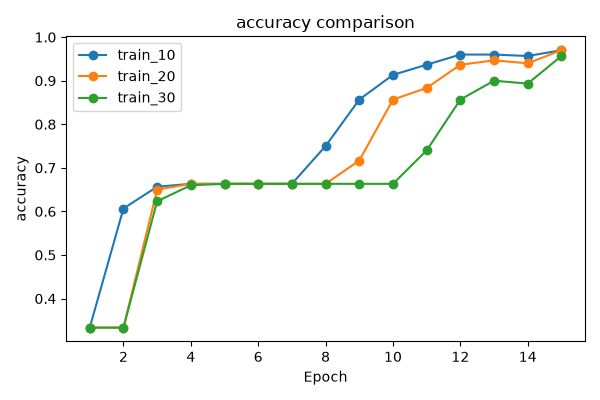

In [6]:
csv_paths = {
    spec['label']: spec['results_dir'] / 'metrics.csv'
    for spec in OPTION2_RUNS
    if (spec['results_dir'] / 'metrics.csv').exists()
}
if csv_paths:
    acc_fig_path = project_root / 'figures' / 'noise_train_accuracy_comparison.png'
    plot_comparison(csv_paths, 'accuracy', acc_fig_path)
    display(Image(filename=str(acc_fig_path)))
else:
    print('No Option 2 metrics found yet.')

## 4. Combining Option 1 and Option 2

Option 1 is a single ideally-trained model evaluated at increasing noise; Option 2 points are models actually trained at 10%/20%/30% noise, each evaluated at its own training noise level. If the Option 2 points sit *above* the Option 1 curve at the same noise level, that's evidence training under noise measurably improves robustness. If they're similar (or below), the architecture's robustness looks more inherent than learned -- both outcomes are valid findings, report what actually happens.

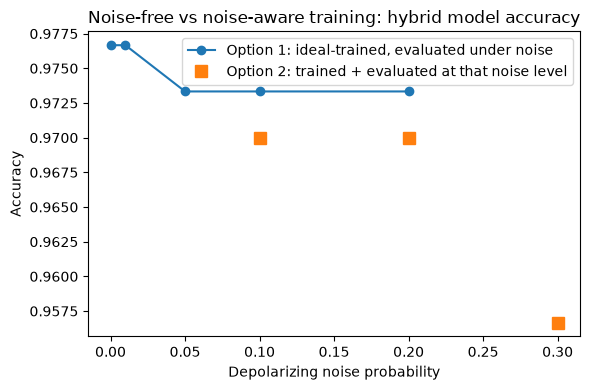

Saved D:\Dissertation\qcnn-dissertation\figures\noise_option1_vs_option2.png


In [7]:
if eval_df is not None and not option2_final_df.empty:
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(
        eval_df['noise_level'], eval_df['accuracy'], marker='o',
        label='Option 1: ideal-trained, evaluated under noise',
    )
    ax.plot(
        option2_final_df['noise_prob'], option2_final_df['accuracy'],
        marker='s', linestyle='none', markersize=9,
        label='Option 2: trained + evaluated at that noise level',
    )
    ax.set_xlabel('Depolarizing noise probability')
    ax.set_ylabel('Accuracy')
    ax.set_title('Noise-free vs noise-aware training: hybrid model accuracy')
    ax.legend()
    fig.tight_layout()
    combined_path = project_root / 'figures' / 'noise_option1_vs_option2.png'
    fig.savefig(combined_path)
    plt.show()
    print(f'Saved {combined_path}')
else:
    print('Need both Option 1 and Option 2 results to build the combined comparison.')

## 5. Confusion matrices

Evaluates the noise-free baseline and each Option 2 model at its own noise level (matching how each was trained), and saves/display a confusion matrix for each.

Saved D:\Dissertation\qcnn-dissertation\results\base\hybrid_subset\confusion_matrix.png


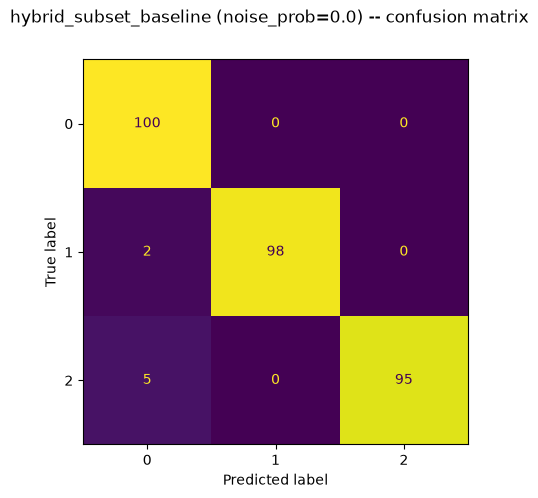

Saved D:\Dissertation\qcnn-dissertation\results\noise\train_10\confusion_matrix.png


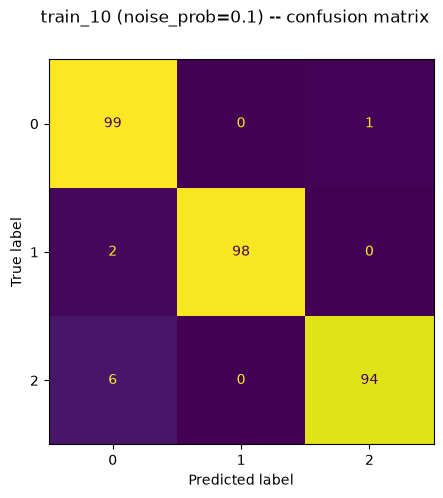

Saved D:\Dissertation\qcnn-dissertation\results\noise\train_20\confusion_matrix.png


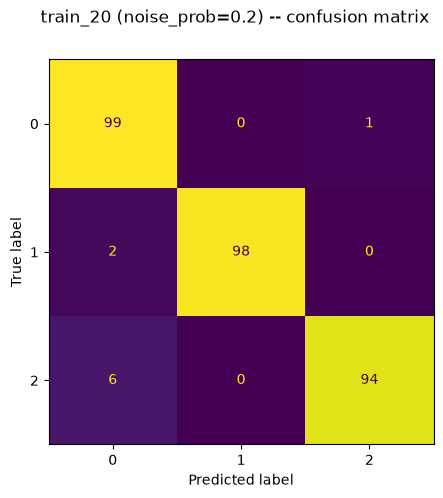

Saved D:\Dissertation\qcnn-dissertation\results\noise\train_30\confusion_matrix.png


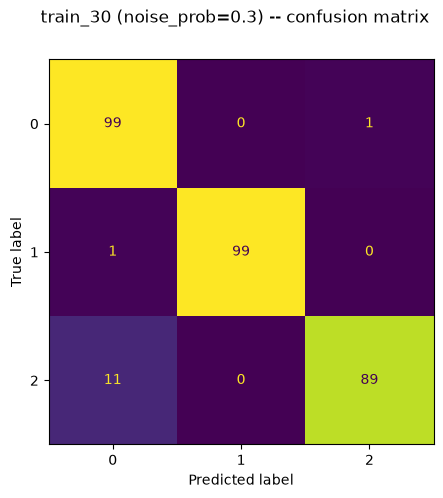

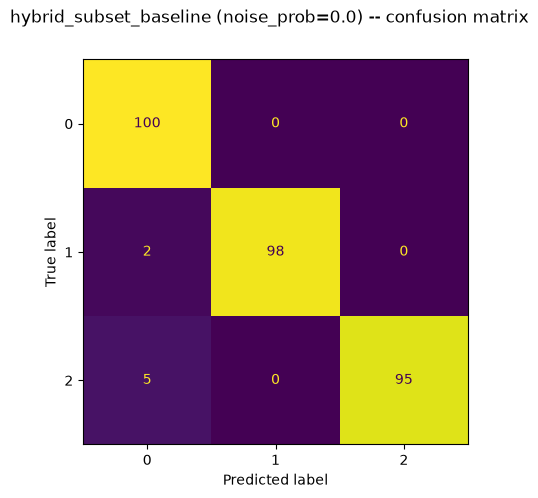

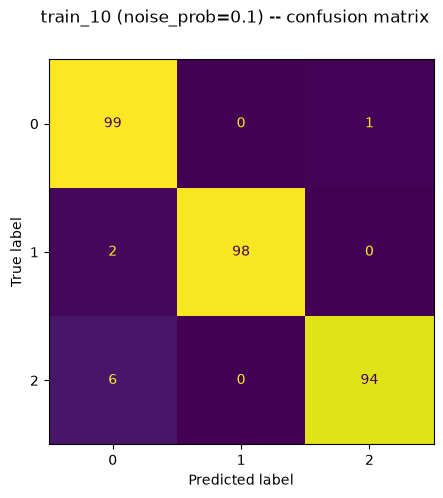

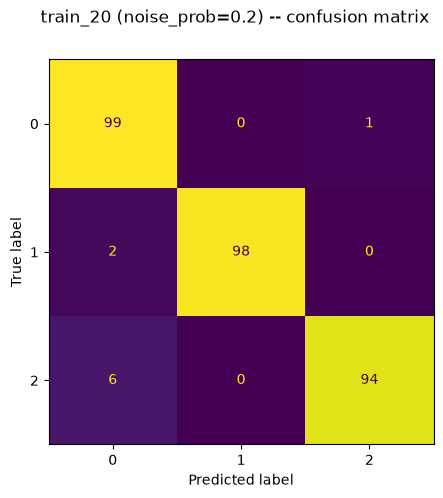

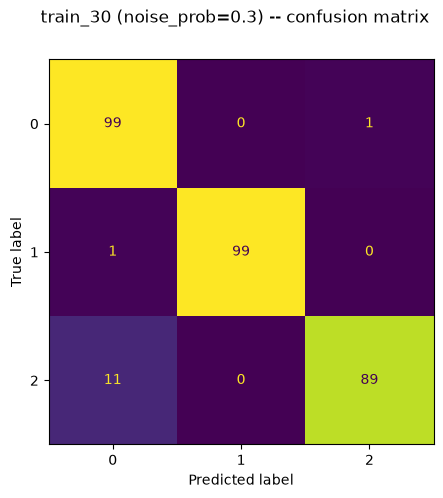

In [8]:
criterion = nn.CrossEntropyLoss()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

for spec in [BASE_HYBRID] + OPTION2_RUNS:
    config = load_config(spec['config'])
    _, test_loader = get_dataloaders(config)

    model_cfg = config['model']
    model = HybridCNN(
        num_classes=model_cfg['num_classes'],
        n_qubits=model_cfg['n_qubits'],
        n_qlayers=model_cfg['n_qlayers'],
        noise_prob=spec['noise_prob'],
    )

    state_path = spec['results_dir'] / 'model.pt'
    if not state_path.exists():
        print(f"{spec['label']}: no saved weights found at {state_path}")
        continue

    model.load_state_dict(torch.load(state_path, map_location='cpu'))
    model.to(device)
    model.eval()

    with torch.no_grad():
        _, preds, labels = evaluate(model, test_loader, criterion, device)

    class_names = [str(c) for c in config['dataset']['classes']]
    fig = confusion_matrix_fig(labels, preds, class_names)
    fig.suptitle(f"{spec['label']} (noise_prob={spec['noise_prob']}) -- confusion matrix")
    out_path = spec['results_dir'] / 'confusion_matrix.png'
    fig.savefig(out_path)
    print(f'Saved {out_path}')
    display(fig)